# Optimizing Website Conversion Through A/B Testing
## Problem Statement
#### This project focuses on analyzing user interaction data to evaluate whether introducing a new webpage design improves conversion rates compared to the existing page. By examining user behavior and conversion outcomes, we aim to identify whether the new design provides a measurable improvement in performance.

## Objective
#### Using Python-based hypothesis testing and descriptive statistics, we analyze the relationship between page type and conversion outcome. The goal is to assess whether the difference in conversion rates between the two groups is statistically significant and whether the new page should replace the old one.

## Research Question
#### Is there a statistically significant difference in conversion rates between users who view the old page and those who view the new page, and does the new page lead to improved user conversions?

# Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import scipy.stats as st
import statsmodels.api as sm


# loading the dataset

In [2]:
df = pd.read_csv(r"C:\ab_testing\ab_test.csv")

In [3]:
df.head()

,id,time,con_treat,page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


In [4]:
df.tail()

,id,time,con_treat,page,converted
294473,751197,28:38.6,control,old_page,0
294474,945152,51:57.1,control,old_page,0
294475,734608,45:03.4,control,old_page,0
294476,697314,20:29.0,control,old_page,0
294477,715931,40:24.5,treatment,new_page,0


# Exploratory data analysis

In [5]:
# rows and columns of the dataset
df.shape

(294478, 5)

In [6]:
# dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         294478 non-null  int64 
 1   time       294478 non-null  object
 2   con_treat  294478 non-null  object
 3   page       294478 non-null  object
 4   converted  294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [7]:
# check for missing values
df.isnull().sum()

id           0
time         0
con_treat    0
page         0
converted    0
dtype: int64

In [8]:
# check for the duplicate rows 
df[df.duplicated()]

,id,time,con_treat,page,converted


In [9]:
# datatypes of the data
df.dtypes

id            int64
time         object
con_treat    object
page         object
converted     int64
dtype: object

In [10]:
# Creating a Minute Column to Analyze Frequent Visit Times
df['time'] = df['time'].astype(str)
df['fixed_time'] = '00:' + df['time']
df['fixed_time'] = pd.to_timedelta(df['fixed_time'])
df['minute'] = df['fixed_time'].dt.seconds//60

In [11]:
# after creating minute column datatypes of the data
df.dtypes

id                      int64
time                   object
con_treat              object
page                   object
converted               int64
fixed_time    timedelta64[ns]
minute                  int32
dtype: object

### The dataset contains multiple columns; however, based on the problem statement, only a subset of these variables is required for the analysis. Therefore, the relevant columns were extracted from the original dataset, while the remaining columns that were not necessary for this study were removed. This step helps simplify the dataset and ensures that the analysis focuses only on the variables relevant to the research objective.

In [12]:
dff = df[['id','con_treat','page','minute','converted']]

In [13]:
dff.head(5)

,id,con_treat,page,minute,converted
0,851104,control,old_page,11,0
1,804228,control,old_page,1,0
2,661590,treatment,new_page,55,0
3,853541,treatment,new_page,28,0
4,864975,control,old_page,52,1


In [14]:
#  (after extracting columns)rows and columns of the dataset
dff.shape

(294478, 5)

In [15]:
# (after extracting columns)
dff.dtypes

id            int64
con_treat    object
page         object
minute        int32
converted     int64
dtype: object

In [16]:
dff[(dff['page'] == 'old_page')&(dff['con_treat'] =='treatment' )]

,id,con_treat,page,minute,converted
308,857184,treatment,old_page,34,0
327,686623,treatment,old_page,26,0
357,856078,treatment,old_page,29,0
685,666385,treatment,old_page,11,0
713,748761,treatment,old_page,47,0
...,...,...,...,...,...
293773,688144,treatment,old_page,34,1
293817,876037,treatment,old_page,15,1
293917,738357,treatment,old_page,37,0
294014,813406,treatment,old_page,25,0


In [17]:
dff[(dff['page'] == 'new_page')&(dff['con_treat'] =='control' )]

,id,con_treat,page,minute,converted
22,767017,control,new_page,58,0
240,733976,control,new_page,11,0
490,808613,control,new_page,44,0
846,637639,control,new_page,9,1
850,793580,control,new_page,25,1
...,...,...,...,...,...
293894,741581,control,new_page,49,0
293996,942612,control,new_page,52,0
294200,928506,control,new_page,32,0
294253,886135,control,new_page,49,0


### During the data exploration process, some mismatched values were identified in the dataset. According to the experiment design, the control group in the con_treat column should correspond to the old_page, while the treatment group should correspond to the **new_page`. However, some rows showed inconsistencies where the control group was associated with the new page.

### To ensure the analysis follows the correct experimental structure, only the records with properly matched values were extracted from the dataset, and these valid observations were used for further analysis.

In [18]:
#  Extracting properly matched values 
dff = dff[((dff['page'] == 'new_page')&(dff['con_treat'] =='treatment' )) | ((dff['page'] == 'old_page')&(dff['con_treat'] =='control' ))]

In [19]:
#  checking shape of extracted dataset
dff.shape

(290585, 5)

In [20]:
#  Descriptive Statistics of the Extracted Data
dff.describe().round()

,id,minute,converted
count,290585.0,290585.0,290585.0
mean,788005.0,30.0,0.0
std,91225.0,17.0,0.0
min,630000.0,0.0,0.0
25%,709035.0,15.0,0.0
50%,787995.0,30.0,0.0
75%,866956.0,45.0,0.0
max,945999.0,59.0,1.0


In [21]:
#  Percentage Distribution of Dataset Variables
for i in dff.columns:
    if dff[i].nunique()<20:
        print(dff[i].value_counts(normalize = True)*100)
        print('*'*50)

con_treat
treatment    50.006366
control      49.993634
Name: proportion, dtype: float64
**************************************************
page
new_page    50.006366
old_page    49.993634
Name: proportion, dtype: float64
**************************************************
converted
0    88.040332
1    11.959668
Name: proportion, dtype: float64
**************************************************


### To examine the distribution of users exposed to different webpage versions, we assess the proportion of the new page and old page in the dataset. To present this information visually, a pie chart is used. This graphical representation provides a clear and intuitive view of how users are distributed between the two page versions, helping us understand whether the experiment groups are balanced.

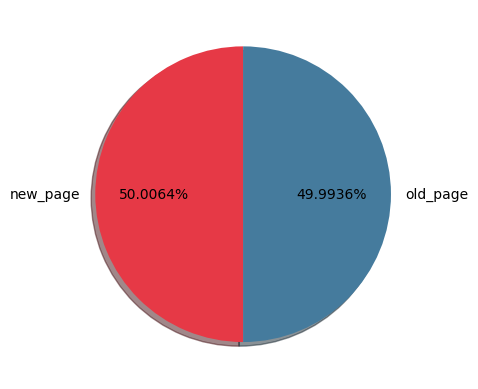

In [30]:
plt.pie(dff['page'].value_counts(normalize = True),labels = dff['page'].value_counts().index ,autopct = '%1.4f%%',shadow = True,startangle = 90,colors = ['#E63946', '#457B9D'])
plt.savefig("plot.png")
plt.show()

### We explore the relationship between page type and conversion status to determine whether users who viewed the new page behave differently from those who viewed the old page. Visualization techniques are used to compare the distribution of conversions across both page types.

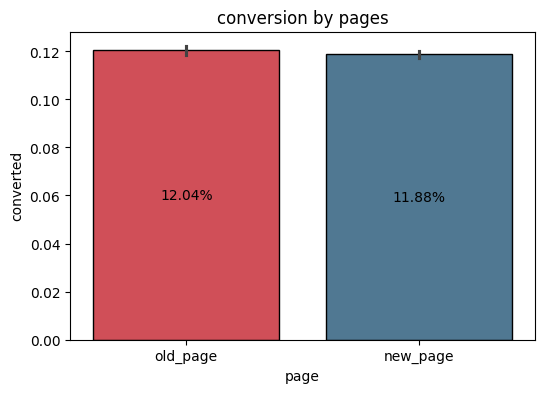

In [32]:
plt.figure(figsize = (6,4))
ax = sns.barplot(x = 'page',y = 'converted',data = dff,edgecolor = 'k',palette = ['#E63946', '#457B9D'])
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x,y = p.get_xy()
    ax.text(x+width/2,y+height/2,'{:.2f}%'.format(height*100),ha = 'center',va = 'center')
plt.title('conversion by pages')
plt.savefig("plt.png")
plt.show()

In [24]:
dff

,id,con_treat,page,minute,converted
0,851104,control,old_page,11,0
1,804228,control,old_page,1,0
2,661590,treatment,new_page,55,0
3,853541,treatment,new_page,28,0
4,864975,control,old_page,52,1
...,...,...,...,...,...
294473,751197,control,old_page,28,0
294474,945152,control,old_page,51,0
294475,734608,control,old_page,45,0
294476,697314,control,old_page,20,0


In [33]:
# Summary Statistics by Page Type
dff.groupby('page').agg({'converted':['mean','std'],'minute':['mean','std']}).round(2)

converted       minute       
              mean   std   mean    std
page                                  
new_page      0.12  0.32  29.53  17.32
old_page      0.12  0.33  29.58  17.28

### To visually examine the distribution of user activity time, a Kernel Density Estimate (KDE) plot was created for the minute variable across different page types. This visualization helps compare how user activity is distributed over time for the old page and the new page, allowing us to observe whether there are noticeable differences in the timing patterns between the two groups

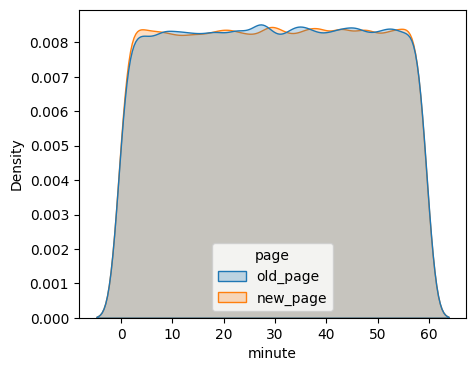

In [31]:
plt.figure(figsize = (5,4))
sns.kdeplot(x = 'minute',data = dff,hue = 'page',fill = True)
plt.savefig("plott.png")
plt.show()

# Hypothesis Testing

### To determine whether the minute variable follows a normal distribution, a Quantile–Quantile (QQ) plot was generated. A QQ plot compares the quantiles of the dataset with the quantiles of a theoretical normal distribution. If the data is normally distributed, the points in the plot will fall approximately along the diagonal reference line.



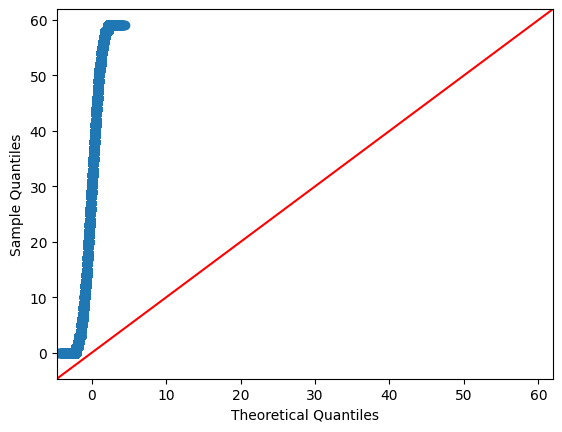

In [27]:
sm.qqplot(dff['minute'],line = '45')
plt.show()

### The QQ plot shows that the data points do not follow the red 45-degree reference line, indicating that the distribution does not follow a normal distribution. Therefore, using a Z-test, which typically assumes a known population standard deviation and normally distributed data, may not be appropriate for this analysis.

### Instead, a T-test is used as it is a more flexible method for hypothesis testing when the population standard deviation is unknown. The T-test can also be applied to both small and large sample sizes, making it a widely used statistical method for comparing the means of two groups.

### In this A/B testing analysis, we aim to compare the behavior of users who viewed the old page and those who viewed the new page. Since the population parameters are unknown and the dataset represents a sample of user interactions, the T-test provides an appropriate approach for determining whether there is a statistically significant difference in conversion behavior between the two page versions.

### **Null Hypothesis (H₀):** There is no difference in conversion rates between the old page and the new page.

### **Alternative Hypothesis (H₁):** There is a difference in conversion rates between the old page and the new page.

In [28]:
#  sample - 1
sample_o = dff[dff['page'] == 'old_page']['minute']
# sample - 2
sample_n = dff[dff['page'] == 'new_page']['minute']


In [29]:
# performing t test on both the different sample
t_stats,p_value = st.ttest_ind(a = sample_o,b =sample_n,equal_var = False )
print('t_stats',t_stats,'p_value',p_value)

# comparing the p value with the significance of 5% or 0.05
if p_value < 0.05:
    print("\nReject the null hypothesis")
else:
    print("\nAccept the null hypothesis")

t_stats 0.8701722811750628 p_value 0.38420698032903267

Accept the null hypothesis


### Since the p-value (0.384) is greater than the significance level of 5%, we fail to reject the null hypothesis. This means there is no statistically significant difference in conversion rates between users who viewed the old page and those who viewed the new page.

### The key business insight from this analysis is that the new page does not significantly improve user conversions compared to the old page. Therefore, based on the available data, there is no strong evidence to support replacing the old page with the new page.